In [84]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"]="2"  # specify which GPU(s) to be used
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os.path
import math

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import plotly
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense , Dropout, Conv2D ,Flatten
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [3]:
CTW_labelled = "/Users/chuansun/Downloads/CTW2020_labelled_data/"

In [4]:
def get_data(data_file):
    
    f = h5py.File(data_file, 'r')
    H_Re = f['H_Re'][:] #shape (sample size, 56, 924, 5)
    H_Im = f['H_Im'][:] #shape (sample size, 56, 924, 5)
    SNR = f['SNR'][:] #shape (sample size, 56, 5)
    Pos = f['Pos'][:] #shape(sample size, 3)
    f.close()
            
    return H_Re, H_Im, SNR, Pos        

# load data from file_1.hdf4

data_file = CTW_labelled+"file_"+str(1)+".hdf5"
H_Re, H_Im, SNR, Pos = get_data(data_file)
print("H_Re is of shape {}".format(H_Re.shape))
print("H_Im is of shape {}".format(H_Im.shape))
print("SNR is of shape {}".format(SNR.shape))
print("Pos is of shape {}".format(Pos.shape))

H_Re is of shape (512, 56, 924, 5)
H_Im is of shape (512, 56, 924, 5)
SNR is of shape (512, 56, 5)
Pos is of shape (512, 3)


In [88]:
# Euclidean norm
H = np.sqrt(H_Re[:,:]**2 + H_Im[:,:]**2)

# Extracting phase
arctan = np.divide(H_Re[:,:], H_Im[:,:])
arctan[np.isnan(arctan)] = math.pi / 2
arctan.shape

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning:

divide by zero encountered in true_divide

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning:

overflow encountered in true_divide

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning:

invalid value encountered in true_divide



(512, 56, 924, 5)

In [104]:
# append phase onto H
h1 = np.empty([512, 56, 924, 10])
for d1 in range(512):
    for d2 in range(56):
        for d3 in range(924):
            h = H[d1][d2][d3]
            phase = arctan[d1][d2][d3]
            h1[d1][d2][d3] = np.vstack((h, phase)).reshape(1,10)[0].shape
        
h1.shape

(512, 56, 924, 10)

In [113]:
# append SNR onto h1
snr_rep = np.repeat(SNR, 2, axis=1).reshape(512, 56, -1)
h2 = np.empty([512, 56, 925, 10])
for d1 in range(512):
    for d2 in range(56):
        h = h1[d1][d2]
        snr = snr_rep[d1][d2]
        h2[d1][d2] = np.vstack((h, snr))
        
h2.shape

(512, 56, 925, 10)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fdc767247f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fdc76724ef0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fdc767244e0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fdc7671e630>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fdc7671e9b0>],
 'means': []}

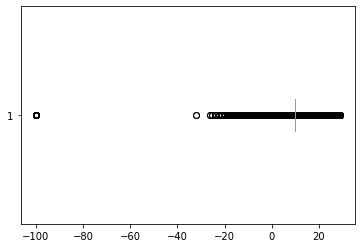

In [115]:
flatten = h2.reshape(-1)
plt.boxplot(flatten, vert=False)

In [ ]:
# h2 = np.empty([512, 56, 66])
# for i in range(56):
#     H2[:,i,:] = pca.transform(H[:,i,:])

In [7]:
# Train test split
x_train, x_test , y_train , y_test = train_test_split(h1, Pos, test_size=0.1, random_state=42)
y_train

array([[ 159.28662567, -327.41968842,  505.9691    ],
       [ 363.90652241,    3.35819798,  500.751     ],
       [  21.48752282, -121.66348421,  508.12      ],
       ...,
       [ 110.97478973, -309.17704875,  506.0858    ],
       [ 108.81043926, -119.09477021,  507.0533    ],
       [ 154.4775817 , -370.13866653,  508.3014    ]])

In [7]:
def keras_model1(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(3,(5,5), input_shape=(x_train.shape[1:]), activation='relu'))
    model.add(Conv2D(6,(5,5), activation='relu'))
    model.add(Conv2D(8,(5,5), activation='relu'))
    model.add(Flatten())
#     model.add(Dense(8192, activation='relu'))
#     model.add(Dense(4096, activation='relu'))
#     model.add(Dense(3072, activation='relu'))
#     model.add(Dense(2048, activation='relu'))
    model.add(Dense(1024, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_absolute_percentage_error', optimizer=opt) 
    return model

In [ ]:
model = keras_model1(opt=Adam(1e-3))
earlystopper = EarlyStopping(patience=50, verbose=1)
#cp = ModelCheckpoint('v1_no_pca.h5', verbose=1, save_best_only=True)
hist = model.fit(x_train, y_train , epochs=200, validation_data=(x_test, y_test),
                 callbacks=[earlystopper], batch_size=4, verbose=1)
#val_loss = hist.history['val_loss']

Epoch 1/200
115/115 [==============================] - 347s 3s/step - loss: 102.0771 - val_loss: 154.4571
Epoch 2/200
115/115 [==============================] - 326s 3s/step - loss: 109.6185 - val_loss: 102.7115
Epoch 3/200
115/115 [==============================] - 321s 3s/step - loss: 88.5296 - val_loss: 106.7427
Epoch 4/200
115/115 [==============================] - 329s 3s/step - loss: 83.3741 - val_loss: 139.6332
Epoch 5/200
115/115 [==============================] - 320s 3s/step - loss: 77.2578 - val_loss: 117.5298
Epoch 6/200
115/115 [==============================] - 326s 3s/step - loss: 72.7698 - val_loss: 145.4074
Epoch 7/200
115/115 [==============================] - 319s 3s/step - loss: 67.4732 - val_loss: 92.0806
Epoch 8/200
115/115 [==============================] - 319s 3s/step - loss: 59.8598 - val_loss: 113.4483
Epoch 9/200
115/115 [==============================] - 319s 3s/step - loss: 54.5816 - val_loss: 97.4853
Epoch 10/200
115/115 [==============================] -

In [28]:
def keras_model2(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(32,(3,3),activation='linear', padding='same',input_shape=x_train.shape[1:]))
    model.add(Conv2D(16,(3,3),activation='linear', padding='same'))
    model.add(Flatten())
    model.add(Dense(512 ,activation = 'relu'))
    model.add(Dense(256 ,activation = 'relu' ))
    model.add(Dense(128 ,activation = 'relu' ))
    model.add(Dense(3))
    model.compile(loss="mean_absolute_percentage_error", optimizer=opt) 
    return model

Modeling after PCA

Try to explore the optimal number for PCA/other DR techniques as well

In [34]:
condense_to = 50
h1_pca = np.empty((h1_3.shape[0], h1_3.shape[1], condense_to, 5))
pca = PCA(n_components=condense_to)


for i in range(h1.shape[1]):
    for j in range(h1.shape[3]):
        h1_pca[:, i, :, j] = pca.fit_transform(h1[:, i, :, j])

h1_pca.shape

(512, 56, 50, 5)

In [ ]:
# n_components = 50
# pca_en = PCA(n_components=n_components)
# pca_result_en = pca_en.fit_transform(H)
# print(pca.explained_variance_ratio_)
# plt.figure()
# plt.plot(np.cumsum(pca_en.explained_variance_ratio_))
# plt.xlabel("Number of Components")
# plt.ylabel("Explained variance ratio")
# plt.title("Explained Variance")
# plt.xticks(np.arange(0, n_components, 1))

In [35]:
# Train test split
x_train, x_test , y_train , y_test = train_test_split(h1_pca, Pos, test_size=0.1, random_state=42)
y_train

array([[ 159.28662567, -327.41968842,  505.9691    ],
       [ 363.90652241,    3.35819798,  500.751     ],
       [  21.48752282, -121.66348421,  508.12      ],
       ...,
       [ 110.97478973, -309.17704875,  506.0858    ],
       [ 108.81043926, -119.09477021,  507.0533    ],
       [ 154.4775817 , -370.13866653,  508.3014    ]])

In [57]:
def keras_model1(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(32,(3,3), input_shape=(x_train.shape[1:]), activation='relu'))
    model.add(Conv2D(16,(3,3), activation='relu'))
    model.add(Conv2D(8,(3,3), activation='relu'))
    #model.add(Conv2D(8,(3,3), activation='relu'))
    model.add(Flatten())
#     model.add(Dense(8192, activation='relu'))
#     model.add(Dense(4096, activation='relu'))
#     model.add(Dense(3072, activation='relu'))
#     model.add(Dense(2048, activation='relu'))
    model.add(Dense(1024, activation='relu'))
    model.add(Dense(512, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_absolute_percentage_error', optimizer=opt) 
    return model


#val_loss = hist.history['val_loss']

Epoch 1/50
115/115 [==============================] - 14s 122ms/step - loss: 93.2242 - val_loss: 222.8803
Epoch 2/50
115/115 [==============================] - 13s 111ms/step - loss: 94.6964 - val_loss: 81.4688
Epoch 3/50
115/115 [==============================] - 13s 111ms/step - loss: 95.4108 - val_loss: 94.2375
Epoch 4/50
115/115 [==============================] - 13s 111ms/step - loss: 85.0648 - val_loss: 118.6551
Epoch 5/50
115/115 [==============================] - 13s 110ms/step - loss: 96.1093 - val_loss: 93.4550
Epoch 6/50
115/115 [==============================] - 13s 113ms/step - loss: 80.3546 - val_loss: 72.4519
Epoch 7/50
115/115 [==============================] - 13s 112ms/step - loss: 72.1168 - val_loss: 78.8149
Epoch 8/50
115/115 [==============================] - 13s 110ms/step - loss: 69.4737 - val_loss: 79.0369
Epoch 9/50
115/115 [==============================] - 13s 109ms/step - loss: 71.6549 - val_loss: 78.1889
Epoch 10/50
115/115 [==============================] 

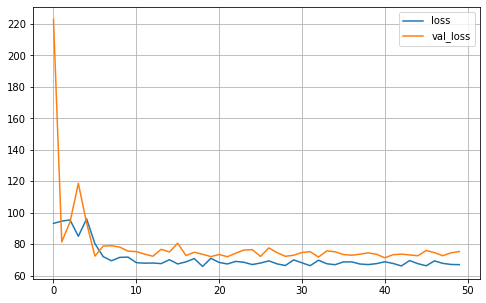

In [58]:
pd.DataFrame(hist.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

Epoch 1/50
115/115 [==============================] - 10s 83ms/step - loss: 91.9537 - val_loss: 103.8214
Epoch 2/50
115/115 [==============================] - 9s 82ms/step - loss: 89.3929 - val_loss: 89.6268
Epoch 3/50
115/115 [==============================] - 9s 78ms/step - loss: 74.6693 - val_loss: 82.6517
Epoch 4/50
115/115 [==============================] - 9s 78ms/step - loss: 125.8321 - val_loss: 97.2173
Epoch 5/50
115/115 [==============================] - 9s 78ms/step - loss: 81.9386 - val_loss: 98.1366
Epoch 6/50
115/115 [==============================] - 9s 77ms/step - loss: 83.8057 - val_loss: 174.2242
Epoch 7/50
115/115 [==============================] - 9s 77ms/step - loss: 112.6022 - val_loss: 99.4569
Epoch 8/50
115/115 [==============================] - 9s 78ms/step - loss: 99.3887 - val_loss: 98.6217
Epoch 9/50
115/115 [==============================] - 9s 77ms/step - loss: 98.6906 - val_loss: 97.6874
Epoch 10/50
115/115 [==============================] - 9s 80ms/step 

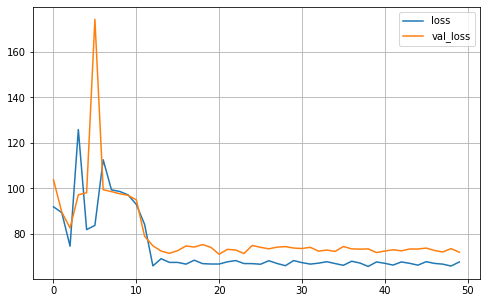

In [59]:
def keras_model2(opt=Adam(1e-3)):
    model = Sequential()
    model.add(Conv2D(32,(3,3),activation='elu', padding='same', input_shape=x_train.shape[1:]))
    model.add(Conv2D(16,(3,3),activation='elu', padding='same'))
    model.add(Conv2D(8,(3,3),activation='elu', padding='same'))
    model.add(Flatten())
    model.add(Dense(512 ,activation='relu'))
    model.add(Dense(256 ,activation='relu'))
    model.add(Dense(128 ,activation='relu'))
    model.add(Dense(64 ,activation='relu'))
    model.add(Dense(3))
    model.compile(loss="mean_absolute_percentage_error", optimizer=opt) 
    return model

model = keras_model2(opt=Adam(5e-3))
earlystopper = EarlyStopping(patience=50, verbose=1)
#cp = ModelCheckpoint('v1_no_pca.h5', verbose=1, save_best_only=True)
hist2 = model.fit(x_train, y_train , epochs=50, validation_data=(x_test, y_test),
                 callbacks=[earlystopper], batch_size=4, verbose=1)
pd.DataFrame(hist2.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()